# Digits — PCA dimensionality sweep

Part of my daily ML practice: one dataset, one question, one notebook.

How many PCA components do you need before logistic regression stops improving on the 8x8 digits?

## Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.model_selection import learning_curve, validation_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso
from sklearn.ensemble import (RandomForestClassifier, RandomForestRegressor,
                              GradientBoostingClassifier, GradientBoostingRegressor,
                              HistGradientBoostingClassifier, VotingClassifier,
                              IsolationForest)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (accuracy_score, roc_auc_score, confusion_matrix,
                             classification_report, mean_squared_error,
                             mean_absolute_error, r2_score, silhouette_score)

from sklearn.datasets import load_digits


## Data

In [ ]:
SEED = 1022
X, y = load_digits(return_X_y=True)
print("shape:", X.shape, "| classes:", np.unique(y).size)


shape: (1797, 64) | classes: 10


## Sweep

components  5: accuracy 0.8289 | variance explained 0.416
components 10: accuracy 0.8933 | variance explained 0.593
components 20: accuracy 0.9422 | variance explained 0.799
components 30: accuracy 0.9667 | variance explained 0.897
components 50: accuracy 0.9711 | variance explained 0.983
components 64: accuracy 0.9733 | variance explained 1.000


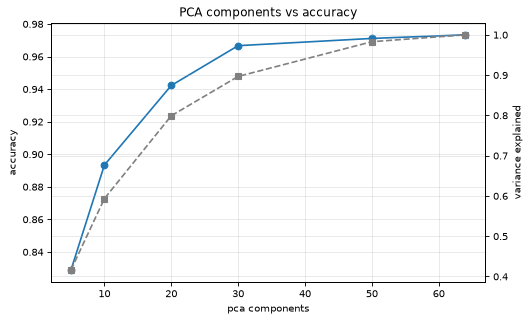

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=SEED, stratify=y)
ns = [5, 10, 20, 30, 50, 64]
accs, varexp = [], []
for n in ns:
    pipe = Pipeline([("scaler", StandardScaler()),
                     ("pca", PCA(n_components=n, random_state=SEED)),
                     ("lr", LogisticRegression(max_iter=2000))])
    pipe.fit(X_train, y_train)
    acc = pipe.score(X_test, y_test)
    ve = pipe.named_steps["pca"].explained_variance_ratio_.sum()
    accs.append(acc); varexp.append(ve)
    print(f"components {n:>2}: accuracy {acc:.4f} | variance explained {ve:.3f}")
fig, ax1 = plt.subplots()
ax1.plot(ns, accs, marker="o", label="accuracy")
ax1.set_xlabel("pca components"); ax1.set_ylabel("accuracy")
ax2 = ax1.twinx()
ax2.plot(ns, varexp, marker="s", ls="--", c="gray", label="variance")
ax2.set_ylabel("variance explained")
ax1.set_title("PCA components vs accuracy")


## Takeaways

- Accuracy saturates around 30 components — the rest is noise for a linear model.
- Nice compression: 64 → 30 dims with no real loss.